# <center> **Пайплайны**

>Пайплайн — это автоматизированный поэтапный процесс выполнения манипуляций с данными, включающий в себя сбор, обработку, генерацию и отбор признаков, обучение модели с последующей её настройкой и проверкой качества. 

В библиотеке scikit-learn пайплайны реализованы как класс **sklearn.pipeline.Pipeline()**. Этот класс может быть использован для сбора воедино отбора и обработки данных вместе с итоговой моделью. 

---

**California Housing Dataset**

* MedInc — медианный уровень дохода в квартале;
* HouseAge — медианный возраст дома в квартале;
* AveRooms — среднее количество помещений;
* AveBedrms — среднее количество спальных комнат;
* Population — население квартала;
* AveOccup — средний срок проживания;
* Latitude — значение широты квартала;
* Longitude — значение долготы квартала;
* Price — целевое значение.

Загрузим датасет и посмотрим на него:

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
 
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
 
data = fetch_california_housing()
df = pd.DataFrame(data['data'], columns=data['feature_names'])
df.loc[:,'target'] = data['target']
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


>Определимся с метрикой, по которой будем оценивать качество модели — **Root Mean Squared Error (RMSE)**, корень из среднего квадрата отклонения. Для этого на метод *mean_squared_error* подадим атрибут *squared = False*, который позволяет управлять возведением метрики в квадрат. Помимо RMSE для оценки качества модели будем использовать метрику **R2**.

In [3]:
def rmse(y_hat, y):
    return mean_squared_error(y_hat, y, squared = False)

Посмотрим на типы данных с помощью метода df.info().

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Видим, что данные исключительно типа float, поэтому мы можем в качестве предобработки применить к ним StandardScaler().

Разделим данные на обучающую и тестовую выборки, используя train_test_split: 

In [5]:
X = df.drop('target', axis=1)
Y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state=42)
print(f'Размер обучающей выборки {X_train.shape}')
print(f'Размер тестовой выборки {X_test.shape}')

Размер обучающей выборки (15480, 8)
Размер тестовой выборки (5160, 8)


Обучим простейший пайплайн, вызвав метод fit(), состоящий из случайного леса и стандартизации (StandardScaler). На вход пайплайна подается список из преобразований в формате кортежа (название метода преобразования, по которому мы будем обращаться в дальнейшем к нашему преобразованию, объект  метода преобразования). Например:

In [6]:
pipeline = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestRegressor())])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('rf', RandomForestRegressor())])

,steps,"[('scaler', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


Посмотрим на метрики. Для этого сделаем предсказание пайплайном с помощью метода predict() и посчитаем R2 и RMSE с помощью функций r2_score() и rmse() соответственно. Округлим результат до четырёх цифр после запятой.

In [8]:
from sklearn.metrics import r2_score, root_mean_squared_error

y_pred = pipeline.predict(X_test)

print(f'Качество по метрике R2: {round(r2_score(y_test, y_pred), 4)}')
print(f'Качество по RMSE: {round(root_mean_squared_error(y_test, y_pred), 4)}')

Качество по метрике R2: 0.8081
Качество по RMSE: 0.504


Теперь мы можем посмотреть на все параметры в пайплайне, вызвав метод get_params():

In [9]:
pipeline.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()), ('rf', RandomForestRegressor())],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'rf': RandomForestRegressor(),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'rf__bootstrap': True,
 'rf__ccp_alpha': 0.0,
 'rf__criterion': 'squared_error',
 'rf__max_depth': None,
 'rf__max_features': 1.0,
 'rf__max_leaf_nodes': None,
 'rf__max_samples': None,
 'rf__min_impurity_decrease': 0.0,
 'rf__min_samples_leaf': 1,
 'rf__min_samples_split': 2,
 'rf__min_weight_fraction_leaf': 0.0,
 'rf__monotonic_cst': None,
 'rf__n_estimators': 100,
 'rf__n_jobs': None,
 'rf__oob_score': False,
 'rf__random_state': None,
 'rf__verbose': 0,
 'rf__warm_start': False}

**Примечание**. В качестве альтернативного метода задания пайплайна можно использовать метод ```make_pipeline```, на вход которого подаются объекты, которые будут использованы в пайплайне. В нашем случае:

In [10]:
from sklearn.pipeline import make_pipeline
make_pipeline(StandardScaler(), RandomForestRegressor())

,steps,"[('standardscaler', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


Использование пайплайна в виде, полученном из make_pipeline, аналогично. 

Попробуем теперь обратиться к отдельной части пайплайна. Попробуем вызвать значение n_estimator у случайного леса. Мы можем это сделать двумя способами: индексацией пайплайна или обращением через имя, которые мы задали ранее при создании ('rf').

In [11]:
print(pipeline[1].n_estimators)
print(pipeline['rf'].n_estimators)

100
100


Теперь попробуем задать этому же параметру значение 200. Можно это сделать, используя метод ```set_params()```, на вход которого надо подавать конструкцию ```<название модуля>__<название параметра>```. 

>Обратите внимание на два нижних подчеркивания, которые используются в качестве литералов для разбиения названия модуля и названия его параметра. Без него компилятор будет неправильно интерпретировать параметр, который вы хотите изменить!

In [12]:
pipeline.set_params(rf__n_estimators=200)

,steps,"[('scaler', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


Данную структуру надо учитывать, когда для пайплайна задается GridSearch кросс-валидация. Попробуем взять 100, 200, 500 базовых моделей и сделать поиск оптимального параметра StardardScaler with_mean (типа bool, который отвечает за центровку данных, приводит распределение к нулевому среднему, по умолчанию — True. В противном случае среднее данных остается неизменным):

In [13]:
from sklearn.model_selection import GridSearchCV
param_grid = {'scaler__with_mean':[True,False],
              'rf__n_estimators':[100, 200, 500]}
grid_search = GridSearchCV(pipeline, param_grid=param_grid, verbose = True)


grid_search.fit(X_train, y_train)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('rf', RandomForestRegressor(n_estimators=500))])


In [14]:
y_pred = grid_search.best_estimator_.predict(X_test)
print(f'Качество по метрике R2: { round(r2_score(y_test, y_pred),4)}')
print(f'Качество по RMSE: {round(root_mean_squared_error(y_test, y_pred), 4)}')

Качество по метрике R2: 0.8098
Качество по RMSE: 0.5017


---

При использовании пайплайна для сборки обработки данных в один стек удобно воспользоваться [Column Transformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html).

*Column Transformer* — это специальный объект из модуля ```compose``` библиотеки *sklearn*, который позволяет применять набор трансформаций к данным. Этот объект позволяет преобразовывать разные столбцы или подмножества столбцов входных данных по отдельности, а результаты, сгенерированные каждым преобразователем, будут объединены в единую таблицу.

Однако, самим *Column Transformer* пользоваться не совсем удобно, для более удобной работы с ним мы будем использовать «обёртку» в виде функции **make_column_transformer()** из того же модуля библиотеки sklearn.

In [15]:
df_wine= pd.read_csv('data_ml8/Red.csv')
df_wine.head()

,Name,Country,Region,Winery,Rating,NumberOfRatings,Price,Year
0,Pomerol 2011,France,Pomerol,Château La Providence,4.2,100,95.00,2011
1,Lirac 2017,France,Lirac,Château Mont-Redon,4.3,100,15.50,2017
2,Erta e China Rosso di Toscana 2015,Italy,Toscana,Renzo Masi,3.9,100,7.45,2015
3,Bardolino 2019,Italy,Bardolino,Cavalchina,3.5,100,8.72,2019
4,Ried Scheibner Pinot Noir 2016,Austria,Carnuntum,Markowitsch,3.9,100,29.15,2016


In [16]:
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8666 entries, 0 to 8665
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             8666 non-null   object 
 1   Country          8666 non-null   object 
 2   Region           8666 non-null   object 
 3   Winery           8666 non-null   object 
 4   Rating           8666 non-null   float64
 5   NumberOfRatings  8666 non-null   int64  
 6   Price            8666 non-null   float64
 7   Year             8666 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 541.8+ KB


Например, у нас есть численный признак цена вина (Price) и категориальный регион производства (Region). Для первого надо применить ```StandardScaler()```, для второго — ```OneHotEncoder()```. Мы можем сделать это следующим образом:

In [17]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
ct = make_column_transformer(
     (StandardScaler(), ['Price']),
    (OneHotEncoder(), ['Country']))
print(ct)

ColumnTransformer(transformers=[('standardscaler', StandardScaler(), ['Price']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['Country'])])


>Примечание. Если мы хотим применить, например, OneHotEncoder, к более чем одному признаку, то просто достаточно добавить в список колонки, например ['Country', ‘Region’]. Теперь OneHotEncoder будет работать не только на признаке Country, но ещё и на Region.

>Примечание. Можно также использовать фильтрацию по типу колонок, используя метод ```make_column_selector()``` из sklearn.compose. Например, следующий Column Transformer будет применять преобразование StandardScaler к числовым столбцам и OneHotEncoder к столбцам с типом данных object:

In [18]:
from sklearn.compose import make_column_selector
import numpy as np

ct_filtered = make_column_transformer(
       (StandardScaler(), make_column_selector(dtype_include=np.number)),
       (OneHotEncoder(), make_column_selector(dtype_include=object))
)

print(ct_filtered)

ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x000002308ACCEEF0>),
                                ('onehotencoder', OneHotEncoder(),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x000002308ACCE3E0>)])


Полученный трансформер можно использовать в качестве элемента пайплайна, например:

In [19]:
pipeline = Pipeline([('ct', ct_filtered), ('rf', RandomForestRegressor())])

Давайте посмотрим на результат работы ColumnTransformer в пайплайне. Для этого обучим его на колонках Price и Country, а в качестве целевой метки используем рейтинг вина Rating.

In [20]:
X = df_wine[['Country', 'Price']]
y = df_wine['Rating']
pipeline.fit(X, y)

,steps,"[('ct', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('standardscaler', ...), ('onehotencoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


>Примечание. В рамках этого примера мы обучаем пайплайн на полной выборке. Применяя эти знания на практике, не забудьте предварительно разделить данные на тренировочную и тестовую выборки, как мы делали это в первой части юнита. Во избежание утечки данных обучайте пайплайн на тренировочной выборке.

Теперь вызовем отдельно ct и преобразуем X. 

Важный момент: при отображении после преобразования ваш датасет будет представлен в виде sparse-матрицы (специальный формат для хранения больших, практически полностью нулевых матриц), поэтому надо будет вызвать метод toarray(). Так же мы можем получить названия колонок с onehotencoder с помощью метода .get_feature_names_out(), обратившись именно к энкодеру. 

In [21]:
pd.DataFrame(
    pipeline['ct'].transform(X).toarray(),
    columns=['Price'] + pipeline['ct'].transformers_[1][1].get_feature_names_out().tolist()
)


,Price,Country_Argentina,Country_Australia,Country_Austria,Country_Brazil,Country_Bulgaria,Country_Canada,Country_Chile,Country_China,Country_Croatia,...,Country_Portugal,Country_Romania,Country_Slovakia,Country_Slovenia,Country_South Africa,Country_Spain,Country_Switzerland,Country_Turkey,Country_United States,Country_Uruguay
0,0.657648,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.278402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.373184,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.358231,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.117684,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8661,-0.266981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8662,-0.224358,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8663,-0.178910,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8664,-0.387784,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---

Обученный пайплайн можно сохранить в формат [pickle](https://docs.python.org/3/library/pickle.html), например, используя библиотеку ```joblib```. Далее его можно использовать после десериализации как решение «из коробки», применяя следующие методы.

>Примечание. Формат pickle реализует двоичный протокол для сериализации/десериализации объектов для сохранения и последующего использования без каких-либо дополнительных преобразований. Удобен для переноса обученных моделей, предобработки и так далее.

>**Сериализация** — процесс перевода структуры данных в последовательность битов. 

>**Десериализация** — процесс создания из последовательности битов  структуры данных.

In [22]:
!pip install joblib
import joblib
joblib.dump(pipeline, 'pipeline.pkl')

['pipeline.pkl']

После этого ваш пайплайн будет сохранен в файл pipeline.pkl. Вы можете использовать свой пайплайн, импортировав все библиотеки из зависимостей (которые импортировались при создании пайплайна), используя следующие строчки кода:

In [23]:
pipeline_loaded = joblib.load('pipeline.pkl')
print(pipeline_loaded)

Pipeline(steps=[('ct',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000002308ACCEBF0>),
                                                 ('onehotencoder',
                                                  OneHotEncoder(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000002308ACF2EF0>)])),
                ('rf', RandomForestRegressor())])


---

In [61]:
df_wine= pd.read_csv('data_ml8/Red.csv')
df_wine.head()

,Name,Country,Region,Winery,Rating,NumberOfRatings,Price,Year
0,Pomerol 2011,France,Pomerol,Château La Providence,4.2,100,95.00,2011
1,Lirac 2017,France,Lirac,Château Mont-Redon,4.3,100,15.50,2017
2,Erta e China Rosso di Toscana 2015,Italy,Toscana,Renzo Masi,3.9,100,7.45,2015
3,Bardolino 2019,Italy,Bardolino,Cavalchina,3.5,100,8.72,2019
4,Ried Scheibner Pinot Noir 2016,Austria,Carnuntum,Markowitsch,3.9,100,29.15,2016


In [62]:
X = df_wine[['Region', 'Country', 'Price']]
y = df_wine['Rating']

In [63]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer
ct = make_column_transformer(
    (OrdinalEncoder(), ['Region']),
    (StandardScaler(), ['Price']),
    (OneHotEncoder(), ['Country']))
print(ct)

ColumnTransformer(transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['Region']),
                                ('standardscaler', StandardScaler(), ['Price']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['Country'])])


In [64]:
pipeline = Pipeline([('ct', ct), ('rf', RandomForestRegressor(random_state=42))])

In [65]:
pipeline.fit(X, y)

,steps,"[('ct', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinalencoder', ...), ('standardscaler', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
df_test = pd.read_csv('data_ml8/Red_test.csv')
df_test.head()

,Name,Country,Region,Winery,Rating,NumberOfRatings,Price,Year
0,Lirac 2017,France,Lirac,Château Mont-Redon,4.3,100,15.50,2017
1,Erta e China Rosso di Toscana 2015,Italy,Toscana,Renzo Masi,3.9,100,7.45,2015
2,Bardolino 2019,Italy,Bardolino,Cavalchina,3.5,100,8.72,2019
3,Ried Scheibner Pinot Noir 2016,Austria,Carnuntum,Markowitsch,3.9,100,29.15,2016
4,Capatosta 2015,Italy,Toscana,Poggio Argentiera,3.8,101,19.90,2015


In [67]:
X_test = df_test[['Country', 'Price', 'Region']]  # порядок столбцов не важен, важно чтобы названия совпадали
y_test = df_test['Rating']

In [54]:
y_pred = pipeline.predict(X_test)

print(f'Качество по метрике R2: {round(r2_score(y_test, y_pred), 4)}')
print(f'Качество по RMSE: {round(root_mean_squared_error(y_test, y_pred), 4)}')

Качество по метрике R2: 0.9393
Качество по RMSE: 0.0765


Задание 6.2
1 point possible (graded)

Теперь попробуем изменить параметры случайного леса в пайплайне, полученном в предыдущем задании.

Измените параметр n_estimators в случайном лесу со значения по умолчанию до 200 , используя метод set_params.

В качестве ответа на задание введите в поле ниже полученный результат по метрике RMSE, округленный до четвёртого знака после запятой.

In [55]:
pipeline.set_params(rf__n_estimators=200)

,steps,"[('ct', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinalencoder', ...), ('standardscaler', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
pipeline.fit(X, y)

,steps,"[('ct', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinalencoder', ...), ('standardscaler', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
y_pred = pipeline.predict(X_test)

print(f'Качество по метрике R2: {round(r2_score(y_test, y_pred), 4)}')
print(f'Качество по RMSE: {round(root_mean_squared_error(y_test, y_pred), 4)}')

Качество по метрике R2: 0.9398
Качество по RMSE: 0.0761


Задание 6.3
1 point possible (graded)

Теперь попробуем добавить стекинг в качестве модели в пайплайн.

Вам следует выполнить следующее:

* Собрать StackingRegressor:
1. В качестве базовых моделей возьмите ридж-регрессию RidgeCV() и решающее дерево.
2. В качестве метамодели возьмите случайный лес с настройками (количество базовых моделей 10).
3. Все базовые модели стекинга модели должны быть с настройками по умолчанию (кроме random_state).
* Зафиксировать random_state=42 (для всех моделей).
* Заменить в пайплайне задачи 6.1 случайный лес на StackingRegressor.
* Обучить модель на тренировочной выборке.

В качестве ответа на задание введите в поле ниже полученный результат по метрике RMSE, округлённый до второго знака после запятой.

In [73]:
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

#Создаем список кортежей вида: (наименование модели, модель)
estimators = [
    ('lr', RidgeCV()),
    ('dt',  DecisionTreeRegressor(random_state=42))
]

In [72]:
ct = make_column_transformer(
    (OrdinalEncoder(), ['Region']),
    (StandardScaler(), ['Price']),
    (OneHotEncoder(), ['Country']))

# Пайплайн: сначала предобработка, потом стекинг
reg = Pipeline(steps=[
    ('preprocess', ct),
    ('stack', StackingRegressor(
        estimators=estimators,
        final_estimator=RandomForestRegressor(n_estimators=10, random_state=42)
    ))
])

# Обучение
reg.fit(X, y)

# Предсказание
y_pred = reg.predict(X_test)

In [74]:
print(f'Качество по метрике R2: {round(r2_score(y_test, y_pred), 4)}')
print(f'Качество по RMSE: {round(root_mean_squared_error(y_test, y_pred), 2)}')

Качество по метрике R2: 0.6562
Качество по RMSE: 0.18


---

# <center> **Metric Learning**

Задачи **Metric Learning** основаны на измерении расстояния между объектами выборки. Такие задачи могут и не иметь явной и однозначной целевой метки, поэтому Metric Learning может использоваться как при обучении с учителем (supervised learning), так и без него (unsupervised learning).

К основным постановкам задач Metric Learning относят задачи **кластеризации**, задачи **поиска ближайших соседей**, задачи **снижения размерности** и **частичного восстановления данных**. Далее мы постараемся разобрать на примере практическое применение методов для задачи снижения размерности и кластеризации. 

Для начала поговорим поговорим про **расстояния**, которые рассматриваются в задачах Metric Learning. Прежде всего стоит объяснить, что такое расстояние в контексте машинного обучения

>Каждый объект выборки можно представить как точку в n-мерном пространстве, где n — количество признаков, которые описывают объект. Тогда **расстояние** есть некоторая мера дистанции между объектами в n-мерном пространстве (расстояние между n-мерными векторами, описывающими объекты). 

На иллюстрации приведена визуализация объектов, описываемых двухмерным пространством (количество признаков равно двум). Мы можем визуализировать также трехмерное пространство и одномерное, однако размерности выше n >3 визуализировать уже сложно.

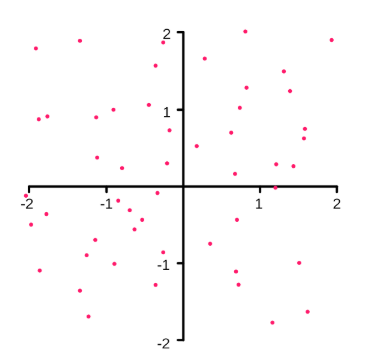

Для понимания расстояния между двумя точками прибегнем к помощи ещё одной иллюстрации: 

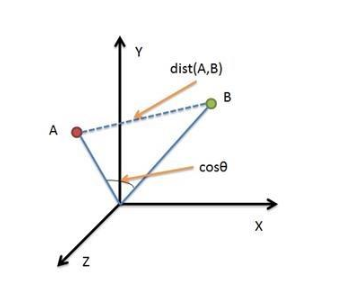

>В данных задачах используется **расстояние Махаланобиса**, обозначаемое далее в формуле как $D$, между объектами $x$ и $x'$  — объектами выборки, описываемыми признаковым пространством (на практике это будут две строки в датасете длиной, равной количеству признаков), вводимое как:
$$D(x,x')=\sqrt{(Lx-Lx')^T(Lx-Lx')}$$

где $L$ — матрица преобразования пространства, например понижение размерности. 

В матричном виде преобразование для каждого вектора данного пространства $x$ в повернутый на угол новый вектор $x'$ имеет вид: 

$x'=Mx$, где в скалярном виде вектор имеет вид $x=[x_x,x_y,x_z]$, а матрица поворота вокруг оси $z$ имеет вид:
$$M_z(\alpha)=
\begin{pmatrix}
cos(\alpha) & -sin(\alpha) & 0 \\
sin(\alpha) & cos(\alpha) & 0 \\
0 & 0 & 1
\end{pmatrix}$$

Размерность матрицы $L$ равна $(m,n)$, где $m$ — размерность преобразованного пространства, $n$ — количество признаков. В случае уменьшения размерности справедливо следующее неравенство:
$$m<n$$



В частном случае, когда $L$ представляет  единичную матрицу, то есть изменений пространства нет и используется для расчета исходное, то такое расстояние является **Евклидовым расстоянием**. Из свойства единичной матрицы имеем для векторного вида евклидового расстояния:
$$Lx=xL=x\to D=\sqrt{(x-x')^T(x-x')}$$

В скалярном виде:
$$D=\sqrt{\sum_{i}^{n}|x_i-x'_i|^2}$$

---

Также в задачах **Metric Learning** используются альтернативные метрики. Рассмотрим некоторые из них.

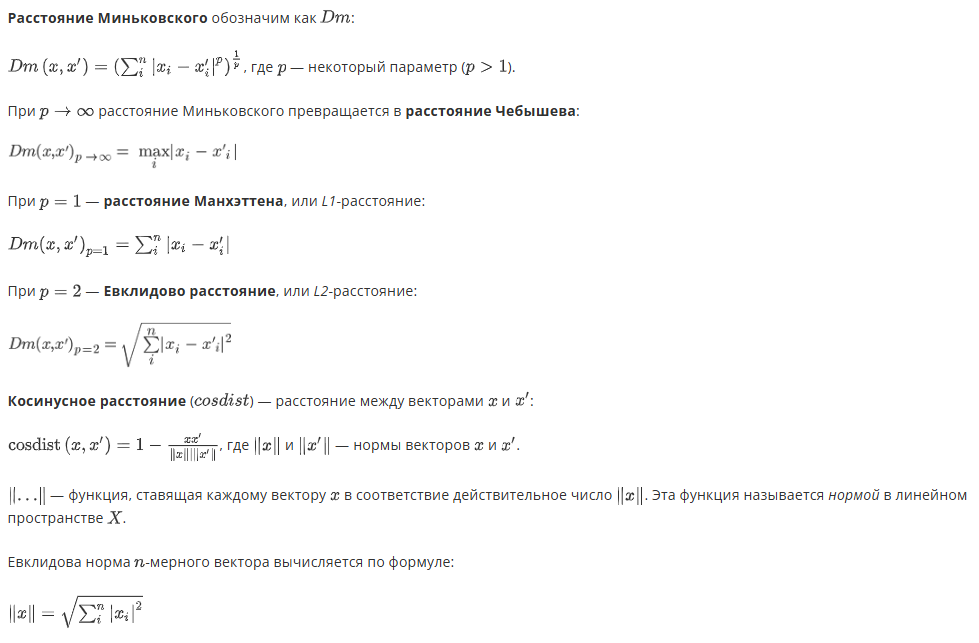

---

## <center> **Метод ближайших соседей. Кластеризация**

В модуле ML-4 мы подробно изучили основные примеры кластеризации. Напомним, что с помощью кластеризации можно разделить пользователей магазина на группы схожих между собой покупателей, можно собрать пользователей сайта в группы по интересам. 

Использование кластеризации здесь обусловлено тем, что у нас нет правильных меток, по которым мы можем классифицировать людей. Кроме того, с помощью кластеризации можно определить тему текста или отнести его к определенной тематике, выяснить, является ли отзыв на сайте позитивным или негативным. Кластеризация также часто используется в медицине, особенно в генетике. 

>Основная сложность задачи кластеризации заключается в том, что не всегда известно истинное значение количества кластеров — иногда надо это исследовать.

Основным методом решения задачи кластеризации является метод **k-means**, с которым мы познакомились ранее. Далее мы попробуем решить с вами реальную задачу на определение кластеров покупателей, где нам будет необходимо определить количество кластеров.

>Задача **поиска ближайших соседей (k Nearest Neighbours, kNN)** очень схожа с задачей кластеризации. Основное отличие заключается в том, что кластеризация — задача разбиения на кластеры, с последующим описанием и интерпретацией общих черт кластера. В свою очередь, поиск ближайших соседей состоит в определении уже существующего кластера, к которому относится объект. 

Другими словами, поиск ближайших соседей используется для задачи обучения с учителем, где целевые метки предварительно могут быть получены, например, кластеризацией. 

Задачи обучения с учителем, где целевые метки получены в результате кластеризации, называются **слабым обучением с учителем (weak supervised learning)**. 

Давайте подробнее разберём работу алгоритма. 

### **Алгоритм работы k-nearest neighbour (KNN)**

* Зададим  k— количество ближайший соседей, по которым принимается решение.
* Выберем расстояние, по которому будут определяться соседи. Обычно это евклидово расстояние, рассмотренное ранее.
* Обучим модель на признаковом пространстве.

    Как было сказано ранее, обучение алгоритма kNN заключается в получении пар **признаковое пространство-целевая метка**. Далее данные нормализуются с использованием **MinMaxScaler()**. Напомним его формулу:
$$X=\frac{X-min[X]}{max[X]-min[X]}$$

* Получим предсказание модели.

Предсказание заключается в поиске k ближайших соседей на основе метрики, выбранной ранее. Данная модель в **sklearn** реализована в модуле *sklearn.neighbors* как [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) для задачи классификации и [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) для задачи регресии. 

Для понимания  работы получения предсказания обратимся к иллюстрации:

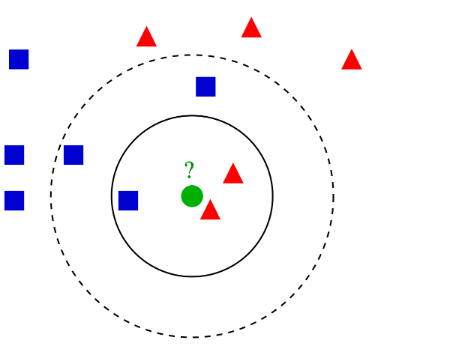

>На рисунке представлена задача бинарной классификации с двумя классами (синие квадраты и красные треугольники). Для нашего объекта, отмеченного зелёным кругом, нам нужно определить класс. 

Стоит отметить, что если k = 3 (в sklearn данный параметр главный и называется ```n_neighbors```), то в радиус трёх ближайших соседей попадают два красных треугольника и один синий квадрат (на рисунке это чёрная линия). Радиус в модели определяется евклидовым расстоянием от классифицируемого объекта, которое рассчитывается различными методами (в sklearn параметр ```algorigthm``` — см. [параметры алгоритма](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)), в том числе и жадным алгоритмом. Итак, большинство представляют объекты класса красных треугольников, и стоит принять класс нашего объекта за класс красных треугольников. В данном случае вероятность верного определения класса равна 0.66 (2/3). 

Однако, если изначально k = 5, то в этом радиусе пятью ближайшими соседями (отмечено чёрным пунктиром) являются уже три синих квадрата и два красных треугольника. Тогда класс объекта определяется как наиболее часто встречаемый класс среди соседей, и объект, вероятнее всего, принадлежит квадратам — в данном случае с вероятностью 0.6, если при предсказании не учитывать расстояние. В случае учёта расстояния (параметр ```weights```, значение ```distance```) при k=5 может случиться так, что наш объект будет классифицирован как красный треугольник, так как у этих двух объектов будет больший вес по причине сильной близости к объекту.

Итак, в ходе данного примера мы узнали смысл некоторых параметров **KNeighborsClassifier**. Давайте подробнее разберём все параметры модели:

* **n_neighbors** — количество  соседей, по умолчанию 5.
* **weights{'uniform', 'distance'}** — вес объекта в зависимости от удаленности от объекта. Как говорилось ранее, если uniform, то расстояние не будет учитываться в подсчёте вероятности для классификации. По умолчанию оно не учитывается, параметр имеет значение 'uniform'. При 'distance' расстояние учитывается.
* **algorithm** — алгоритм, используемый при подсчёте расстояния.
    * 'ball_tree' использует BallTree.
    * 'kd_tree' использует  KDTree.
    * 'brute' использует жадный алгоритм.
    * 'auto' выбирает оптимальный из вышепредставленных.
* **leaf_size** — параметр для поиска расстояния BallTree или KDTree. По умолчанию равен 30.
* **p** — значение p-метрики Миньковского. Как мы знаем, $p=1$ — расстояние Манхэттена (L1), $p=2$ — Евклидово расстояние (L2). По умолчанию $p=2$.
* **metric** — метрика для оценки расстояний, по умолчанию расстояние Миньковского.
* **n_jobs** — количество задач, выполняемых параллельно, ограничено количеством ядер вычислительной машины. При n_jobs=-1 использует все.

Приведём пример: 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')
from sklearn.neighbors import KNeighborsClassifier

Сформируем искусственные данные: 

In [2]:
data = pd.DataFrame([[0,0,0],[0.2,0.1,0], [1,0,0], [2,1,1],[2.5,0.9,1], [3,1,1]], columns = ['x','y', 'target'])

Отделим матрицу признаков и вектор-столбец правильных ответов: 

In [3]:
X = data.drop(['target'],axis = 1)
Y = data['target']

Обучим kNN с тремя соседями:

In [5]:
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X, Y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Посмотрим на визуализацию исходных данных и работы модели по классификации точки. Вероятность принадлежности к классу можно вычислить методом **predict_proba()**, а само предсказание — методом **predict**:

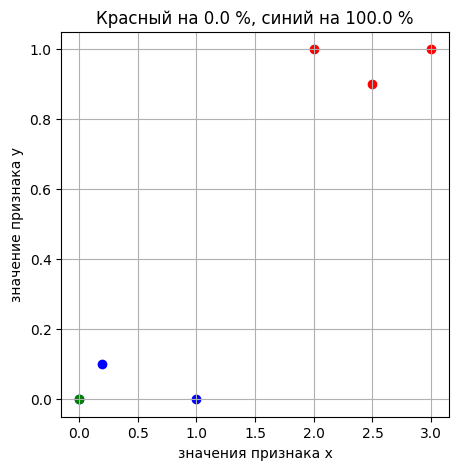

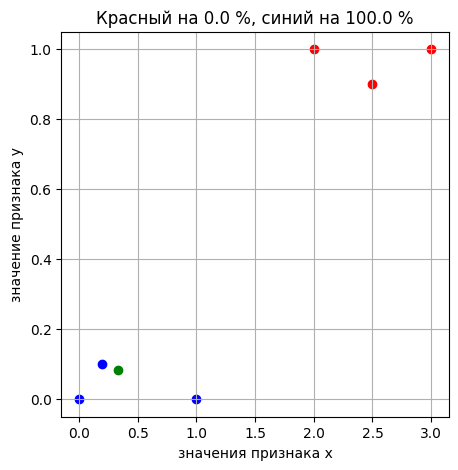

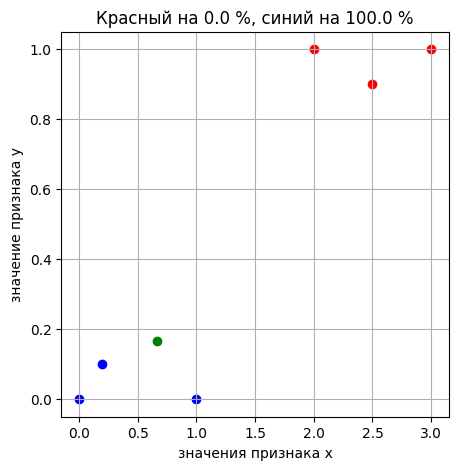

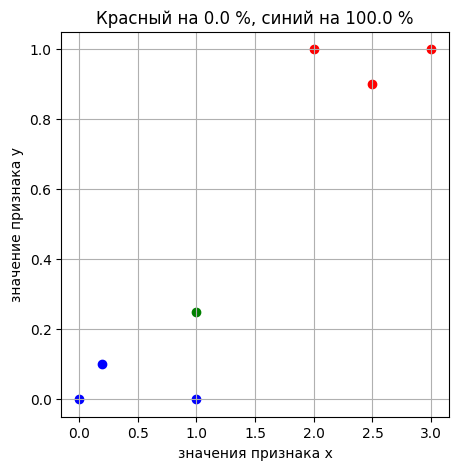

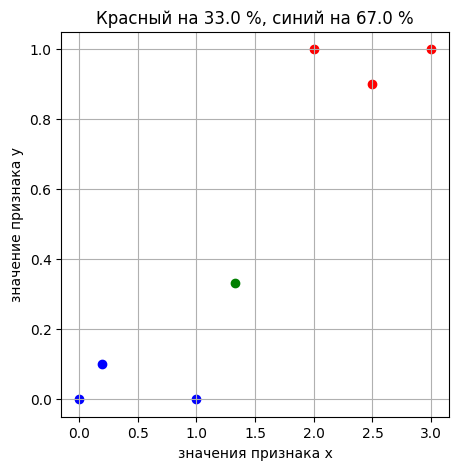

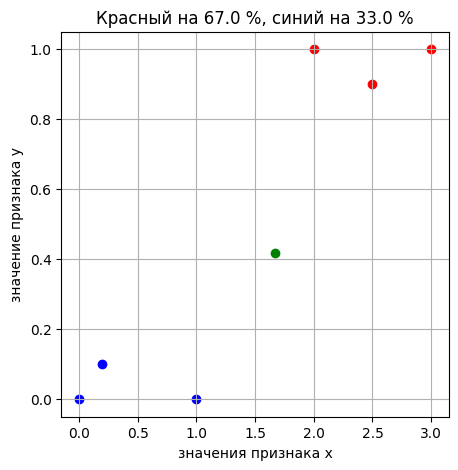

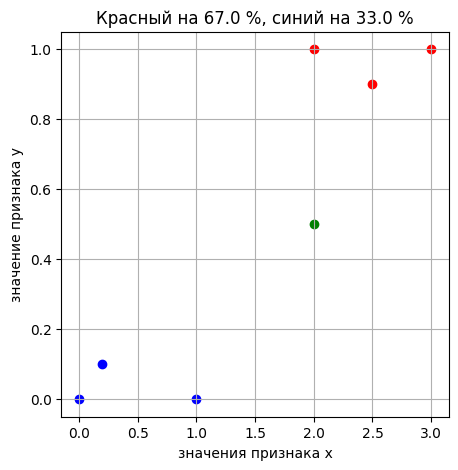

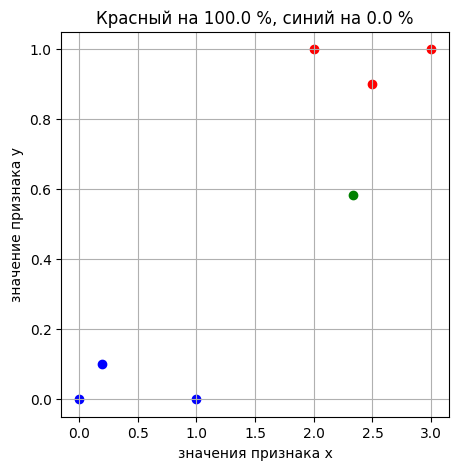

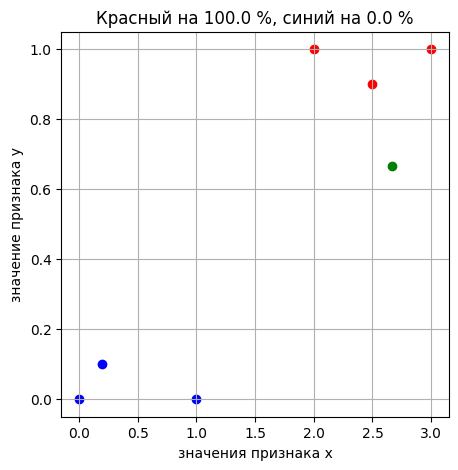

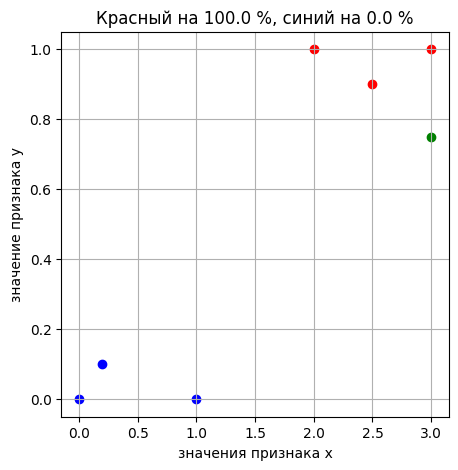

In [6]:
for item in np.linspace(0,3,10):
    x = item
    y = item*0.25
    plt.figure(figsize = (5,5))
    red = data[data.target == 1]
    blue = data[data.target == 0]
    red_prob = round(neigh.predict_proba([[x,y]])[0][1],2)*100 #вероятность принадлежности к красным
    blue_prob = round(neigh.predict_proba([[x,y]])[0][0],2)*100 #вероятность принадлежности к синим
    plt.title(f'Красный на {red_prob} %, синий на {blue_prob} %')
    plt.xlabel('значения признака x')
    plt.ylabel('значение признака y')
    plt.scatter(red.x.values,red.y.values ,c= 'r')
    plt.scatter(blue.x.values,blue.y.values ,c= 'b')
    plt.scatter(x,y ,c= 'g')
    plt.grid()
    plt.show()

Как можно видеть, когда зеленая точка «улетает» из кластера синих точек, вероятность падает, при этом вероятность принадлежности к классу в данном случае может принимать всего четыре значения (0, 0.33, 0.66, 1) в зависимости от количества соседей, так как не учтено расстояние при подсчёте вероятности. 

Попробуем учесть расстояние. Для этого в модель подадим параметр ```weights='distance'```.

In [7]:
neigh = KNeighborsClassifier(n_neighbors=3, weights='distance')
neigh.fit(X, Y)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


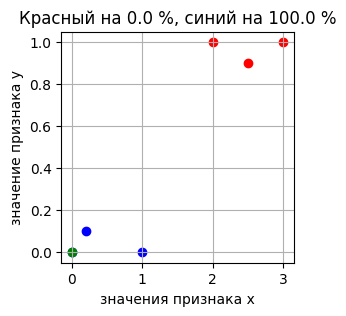

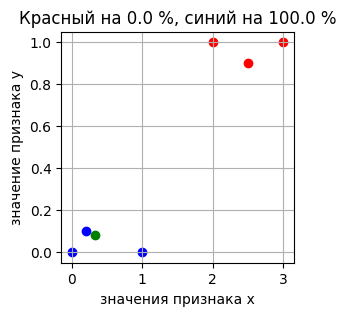

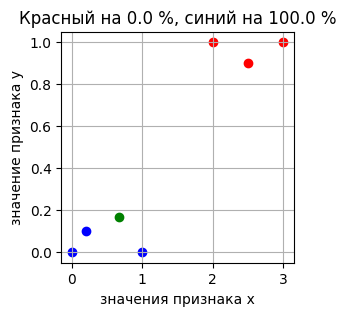

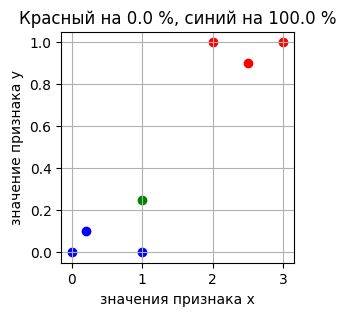

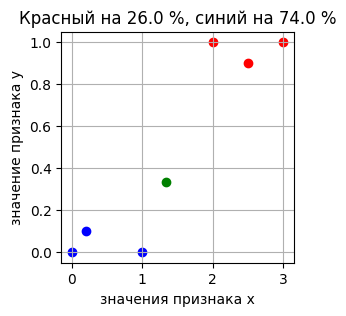

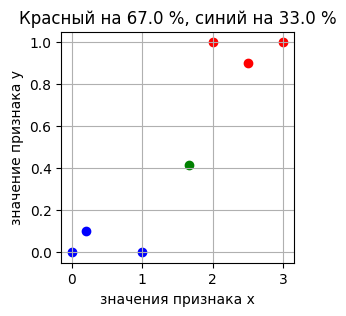

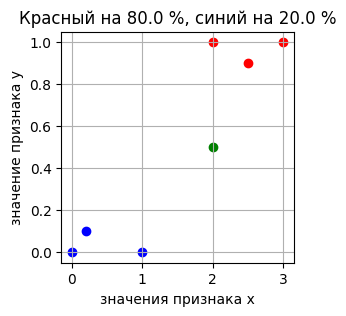

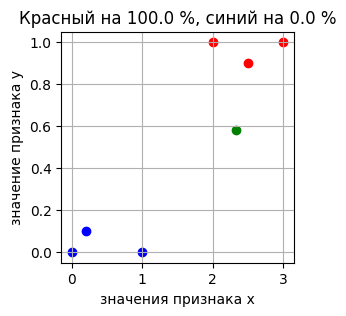

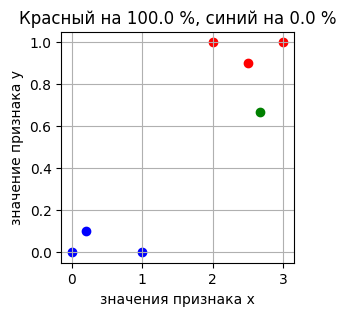

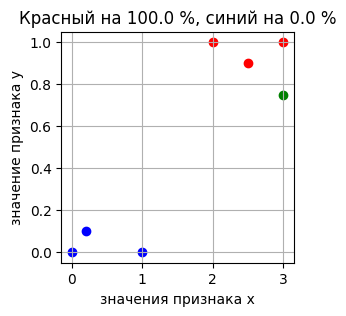

In [8]:
for item in np.linspace(0,3,10):
    x = item
    y = item*0.25
    plt.figure(figsize = (3,3))
    red = data[data.target == 1]
    blue = data[data.target == 0]
    red_prob = round(neigh.predict_proba([[x,y]])[0][1],2)*100 #вероятность принадлежности к красным
    blue_prob = round(neigh.predict_proba([[x,y]])[0][0],2)*100 #вероятность принадлежности к синим
    plt.title(f'Красный на {red_prob} %, синий на {blue_prob} %')
    plt.xlabel('значения признака x')
    plt.ylabel('значение признака y')
    plt.scatter(red.x.values,red.y.values ,c= 'r')
    plt.scatter(blue.x.values,blue.y.values ,c= 'b')
    plt.scatter(x,y ,c= 'g')
    plt.grid()
    plt.show()

Как видим, теперь вероятности могут принимать абсолютно любые значения и точнее предсказывать вероятность принадлежности к классу.

Примечание. В случае задачи регрессии целевая метка нашего объекта определяется как среднее значение целевой метки по k ближайшим соседям.

Расчёты ведутся точно так же, только вместо вероятности предсказания класса высчитывается среднее по ближайшим соседям. Также при использовании взвешенного подхода, среднее уже будет взвешенным в зависимости от расстояния до соседа: чем ближе к точке, тем больший вклад соседа.

Предположим, целевая метка у трёх ближайших соседей в нашем случае равна 0.2, 0.3 и 0.8 соответственно, целевая метка без учёта расстояния равна (0.2+0.3+0.8)/3 = 0.43. 

---

## <center> **Снижение размерности**

Снижение размерности также является основной задачей Metric Learning. Её суть заключается в снижении размерности признакового пространства с сохранением информативности для дальнейшей работы с уменьшенным признаковым пространством в различных задачах, например задачах классификации или кластеризации. 

Тем самым, мы можем найти некоторое пространство, в котором мы можем достаточно точно разделить наши объекты по кластерам/классам или вовсе найти такое представление данных, в которых наша задача будет решаться тривиальным образом. Чаще всего это требуется для задач, в которых **ограничены ресурсы**, например для вычисления моделей на мобильных устройствах, а также для большей интерпретируемости результатов модели. 

>Тем самым мы, претерпевая небольшие потери в качестве моделей и данных, получаем гораздо менее ресурсоемкие результаты, которые можно далее визуализировать.

Основным методом снижения размерности в задачах кластеризации является **PCA (principal component analysis, метод главных компонент)**, с которым мы познакомились в курсе ранее. 

Это один из самых интересных подходов в Metric Learning, так как мы ищем пространство меньшего размера, в котором будет максимально сохранена информация о дисперсии. В этом методе заключены преобразования пространства, поиск расстояний, проекция данных на полученный новый базис. 